<a href="https://www.kaggle.com/code/nikita2901699/homework-nn?scriptVersionId=294457914" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [40]:
import torch  
from torchvision import datasets, transforms

In [41]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [42]:
dataset = datasets.ImageFolder(data_dir)

In [43]:
len(dataset)

16854

In [44]:
img, label = dataset[3526]

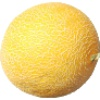

In [45]:
img 

In [46]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [47]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [48]:
len(data_train)

13484

In [49]:
len(data_test)


3370

In [50]:
img, label = data_train[5000]


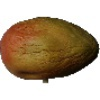

In [51]:
img

In [52]:
train_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomRotation(180, fill=255),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])


In [53]:
train_transform(img).shape

torch.Size([3, 200, 200])

In [54]:
test_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
    transforms.ToTensor()
    ]
)

In [55]:
test_transform(img).shape


torch.Size([3, 200, 200])

In [56]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [57]:
train_data = TransformDataset(data_train,train_transform)


In [58]:
test_data = TransformDataset(data_test,test_transform)


In [59]:
len(test_data)


3370

In [60]:
test_data[666]

(tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
          [0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
          [0.9961, 0.9961, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ...,

In [61]:
train_loader = DataLoader(train_data, batch_size=256)


In [62]:
test_loader = DataLoader(test_data, batch_size=256)


In [63]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([42, 3, 200, 200])
torch.Size([42])


(200, 200, 3)


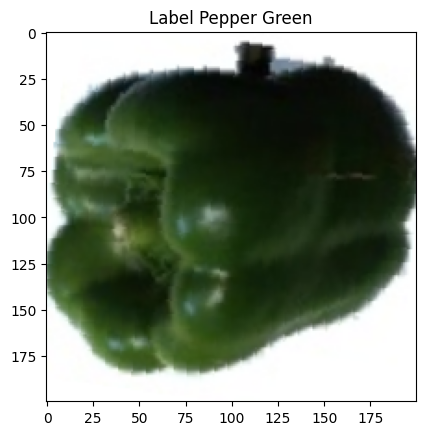

(200, 200, 3)


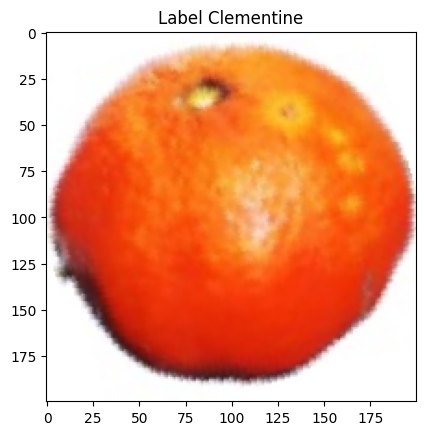

(200, 200, 3)


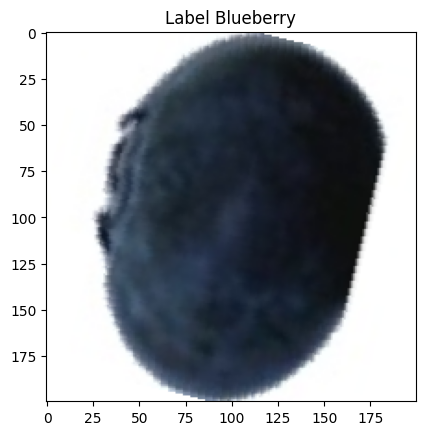

In [64]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

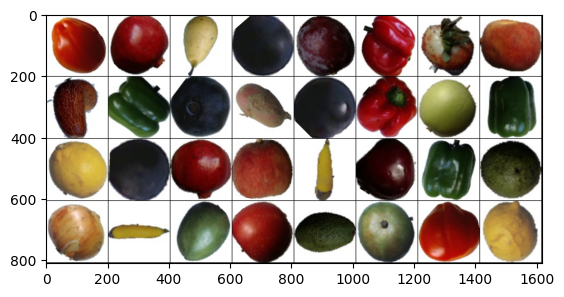

In [65]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [66]:
3*64*64

12288

In [67]:
from torch import nn

# model = nn.Sequential(
#     nn.Flatten(),
#     nn.Linear(12288, 256),
#     nn.ReLU(),
#     nn.Linear(256, 128),
#     nn.ReLU(),
#     nn.Linear(128, 64),
#     nn.ReLU(),
#     nn.Linear(64, 33)
# )

model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding='same'),# розмір буде 8,200,200
    nn.ReLU(),
    nn.MaxPool2d(2,2), #8, 100 , 100
    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding='same'),#16, 100, 100
    nn.ReLU(), # 16, 100, 50
    nn.MaxPool2d(2, 2), # 16, 50, 50
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'), #32, 50, 50
    nn.ReLU(), #32, 50, 50
    nn.MaxPool2d(2, 2), # 32, 25, 25

    nn.Flatten(), # 32*25*25 - 20000
    nn.Linear(20000, 64),
    nn.ReLU(),
    nn.Linear(64, 33)
)

device = 'cuda'
model = model.to(device)



In [68]:
32*25*25

20000

In [69]:
for imgs, labels  in train_loader:
    break

In [70]:
imgs.shape

torch.Size([256, 3, 200, 200])

In [74]:
imgs = imgs.to(device)

In [75]:
res = model(imgs)
res.shape 

torch.Size([256, 33])

In [77]:
# функция ошибки для задачи многоклассовой классификации
loss_fn = nn.CrossEntropyLoss()

# оптимизатор Adam для обучения нейронной сети
optimizer = torch.optim.Adam(
    model.parameters(),   # параметры модели
    lr=0.001
)

# список для сохранения значений loss во время обучения
loss_list = []
loss_test_list = []

# цикл обучения по эпохам
for i in range(3):

    # перебор батчей из обучающего даталоадера
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        loss.backward()               # вычисление градиентов
        optimizer.step()              # обновление весов модели
        optimizer.zero_grad()         # очистка градиентов

        loss_list.append(loss.cpu().item())  # сохранение значения loss

    #test data
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        

        loss_test_list.append(loss.cpu().item())  # сохранение значения loss

loss: 3.7089829444885254
loss: 3.598703384399414
loss: 3.537137269973755
loss: 3.5868115425109863
loss: 3.519116163253784
loss: 3.6859467029571533
loss: 3.634945869445801
loss: 3.6419031620025635
loss: 3.6135759353637695
loss: 3.6351685523986816
loss: 3.699655532836914
loss: 3.569622039794922
loss: 3.6555871963500977
loss: 3.6027605533599854
loss: 3.607353448867798
loss: 3.567446708679199
loss: 3.6316733360290527
loss: 3.624660015106201
loss: 3.58583664894104
loss: 3.5779404640197754
loss: 3.5688939094543457
loss: 3.5295441150665283
loss: 3.60219669342041
loss: 3.5693459510803223
loss: 3.574481248855591
loss: 3.5542616844177246
loss: 3.5947577953338623
loss: 3.559387445449829
loss: 3.666358470916748
loss: 3.603468656539917
loss: 3.632892608642578
loss: 3.6769895553588867
loss: 3.5776190757751465
loss: 3.5483601093292236
loss: 3.5894269943237305
loss: 3.634216785430908
loss: 3.597768545150757
loss: 3.6583728790283203
loss: 3.5566248893737793
loss: 3.642549991607666
loss: 3.6668992042541

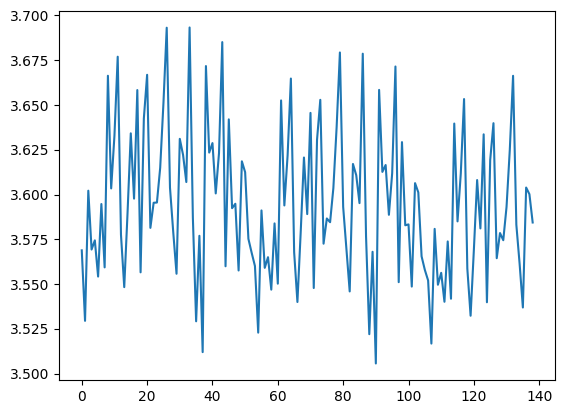

In [78]:
import matplotlib.pyplot as plt

new_list = loss_list[20 :]

plt.plot(new_list)


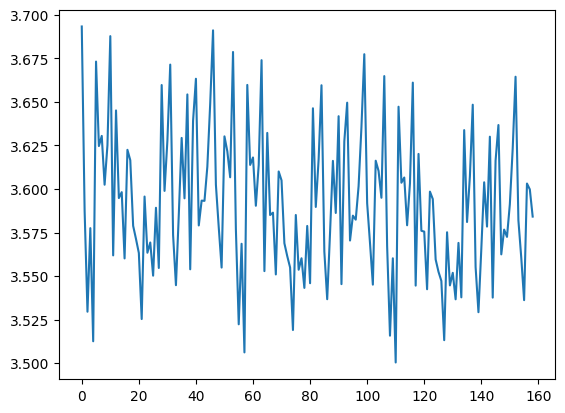

In [79]:
plt.plot(loss_test_list)

In [80]:
img, label = train_data[100]
img = img.unsqueeze(0)
img.shape

torch.Size([1, 3, 200, 200])

In [81]:
img = img.to(device)
prediction = model(img)
print(label)
print(nn.Softmax()(prediction))

31
tensor([[0.0151, 0.0324, 0.0063, 0.0055, 0.0404, 0.0310, 0.0329, 0.0414, 0.0327,
         0.0267, 0.0359, 0.0261, 0.0622, 0.0175, 0.0142, 0.0321, 0.0308, 0.0322,
         0.0349, 0.0323, 0.0364, 0.0344, 0.0104, 0.0354, 0.0470, 0.0306, 0.0330,
         0.0319, 0.0325, 0.0322, 0.0107, 0.0482, 0.0346]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [83]:
result = model(imgs)

In [84]:
res1 = result.argmax(dim=1)

In [85]:
labels

tensor([ 8, 32, 27, 27, 30, 27, 28,  1, 17, 20,  2, 14,  1, 28,  9, 29,  6,  5,
        25, 22, 13,  5, 16, 24,  9, 23, 25, 14, 29, 32,  7, 22, 10, 18, 27, 17,
        19,  0, 16,  5,  9,  6, 24,  3, 31,  9,  7, 31, 16, 15,  5, 20,  5, 18,
        24, 14, 12, 12, 19, 29, 19, 20, 27, 17, 10, 12, 31,  9, 28,  6, 13, 31,
        15,  6, 31, 27,  2, 31,  9,  4,  5,  3, 19,  4, 28,  2, 21, 24, 12, 24,
        19, 31, 20, 30, 26, 30, 22,  3, 19,  9, 31, 26,  9, 32, 27, 17,  4, 31,
        15, 31,  2, 22,  5, 12, 31, 19,  8, 23, 30,  8,  6, 31, 19, 23, 18, 23,
         1, 30,  5, 22, 32, 18, 30, 29, 12, 32, 31, 15,  1, 19, 31, 22,  6, 32,
        16, 14, 11, 30,  9, 22, 15, 31,  3, 19, 17,  6, 29, 18, 27, 27,  7, 13,
        30, 22, 29, 18, 23, 19,  2, 17, 23, 21], device='cuda:0')

In [99]:
res2 = res1 == labels

In [96]:
res2.sum()

tensor(6, device='cuda:0')

In [100]:
count = 0



for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count) 

768


In [103]:
len(train_data) 

13484

In [104]:
768/13484

0.056956392761791756